In [1]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import random
from random import sample

random.seed(42)

In [2]:
with open('hin/hin_train.jsonl', 'r') as f:
    data = f.readlines()
data = [json.loads(line) for line in data]
data[0], len(data)

({'unique_identifier': 'hin1',
  'native word': 'जन्मदिवस',
  'english word': 'janamdivas',
  'source': 'Dakshina',
  'score': None},
 1299155)

In [3]:
# Remove duplicates
# seen_english = set()
# seen_hindi = set()
# data_dedup = []
# for item in data:
#     eng_word = item['english word']
#     hindi_word = item['native word']
#     if eng_word not in seen_english and hindi_word not in seen_hindi:
#         data_dedup.append(item)
#     seen_english.add(eng_word)
#     seen_hindi.add(hindi_word)
# len(data_dedup)
data_dedup = data

In [4]:
word_lens_english = [len(item['english word']) for item in data_dedup]
word_lens_native = [len(item['native word']) for item in data_dedup]

(array([3.00000e+01, 2.87000e+02, 8.39500e+03, 3.04560e+04, 8.49510e+04,
        1.56834e+05, 2.00743e+05, 2.03244e+05, 1.79803e+05, 1.42749e+05,
        1.02241e+05, 7.00830e+04, 4.60380e+04, 2.91040e+04, 1.81060e+04,
        1.07150e+04, 6.56000e+03, 3.92500e+03, 2.20600e+03, 1.33800e+03,
        7.26000e+02, 3.31000e+02, 1.63000e+02, 8.20000e+01, 2.60000e+01,
        1.10000e+01, 3.00000e+00, 0.00000e+00, 4.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
        27., 28., 29., 30., 31., 32., 33.]),
 <BarContainer object of 32 artists>)

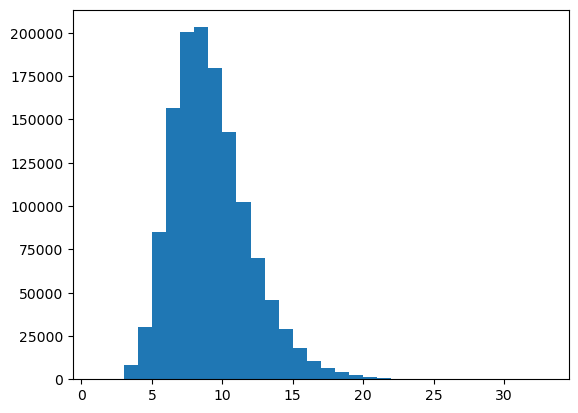

In [5]:
plt.hist(word_lens_english, bins=range(1, max(word_lens_english)+2))

(array([3.00000e+01, 5.99000e+02, 8.65000e+03, 6.07850e+04, 1.57392e+05,
        2.20818e+05, 2.16349e+05, 1.99808e+05, 1.47928e+05, 1.08223e+05,
        7.01780e+04, 4.51970e+04, 2.73170e+04, 1.61440e+04, 9.14500e+03,
        5.06700e+03, 2.92600e+03, 1.66800e+03, 8.21000e+02, 5.90000e+01,
        2.30000e+01, 1.50000e+01, 6.00000e+00, 1.00000e+00, 2.00000e+00,
        3.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
        27., 28., 29.]),
 <BarContainer object of 28 artists>)

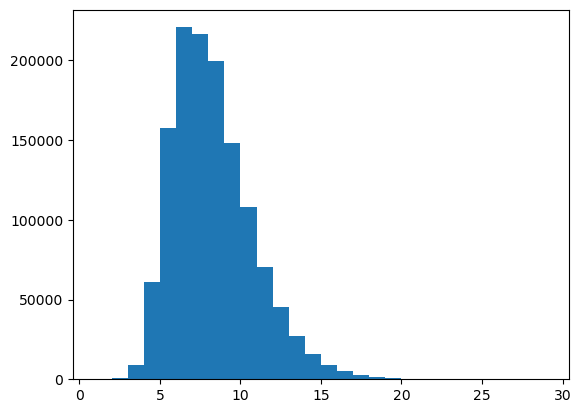

In [6]:
plt.hist(word_lens_native, bins=range(1, max(word_lens_native)+2))

In [7]:
# bins = [(1, 5), (6, 10), (11, 15), (16, 35)]
bins = [(1, 4), (5, 8), (9, 12), (13, 16), (17, 35)]
binned_data = defaultdict(list)

for item in data_dedup:
    eng_len = len(item['english word'])
    for b in bins:
        if b[0] <= eng_len <= b[1]:
            binned_data[b].append(item)
            break

In [8]:
[(len(binned_data[b]), b) for b in bins]

[(39168, (1, 4)),
 (645772, (5, 8)),
 (494876, (9, 12)),
 (103963, (13, 16)),
 (15376, (17, 35))]

In [9]:
lens_chosen = [7000, 35000, 35000, 15000, 8000]

In [10]:
chosen_data = []

for i, b in enumerate(bins):
    chosen_data.extend(sample(binned_data[b], lens_chosen[i]))

In [11]:
with open('hin/hin_train_chosen.jsonl', 'w') as f:
    for item in chosen_data:
        f.write(json.dumps(item) + '\n')